In [2]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# eigenvalue splitting

numerically computed evals using mathematica code...

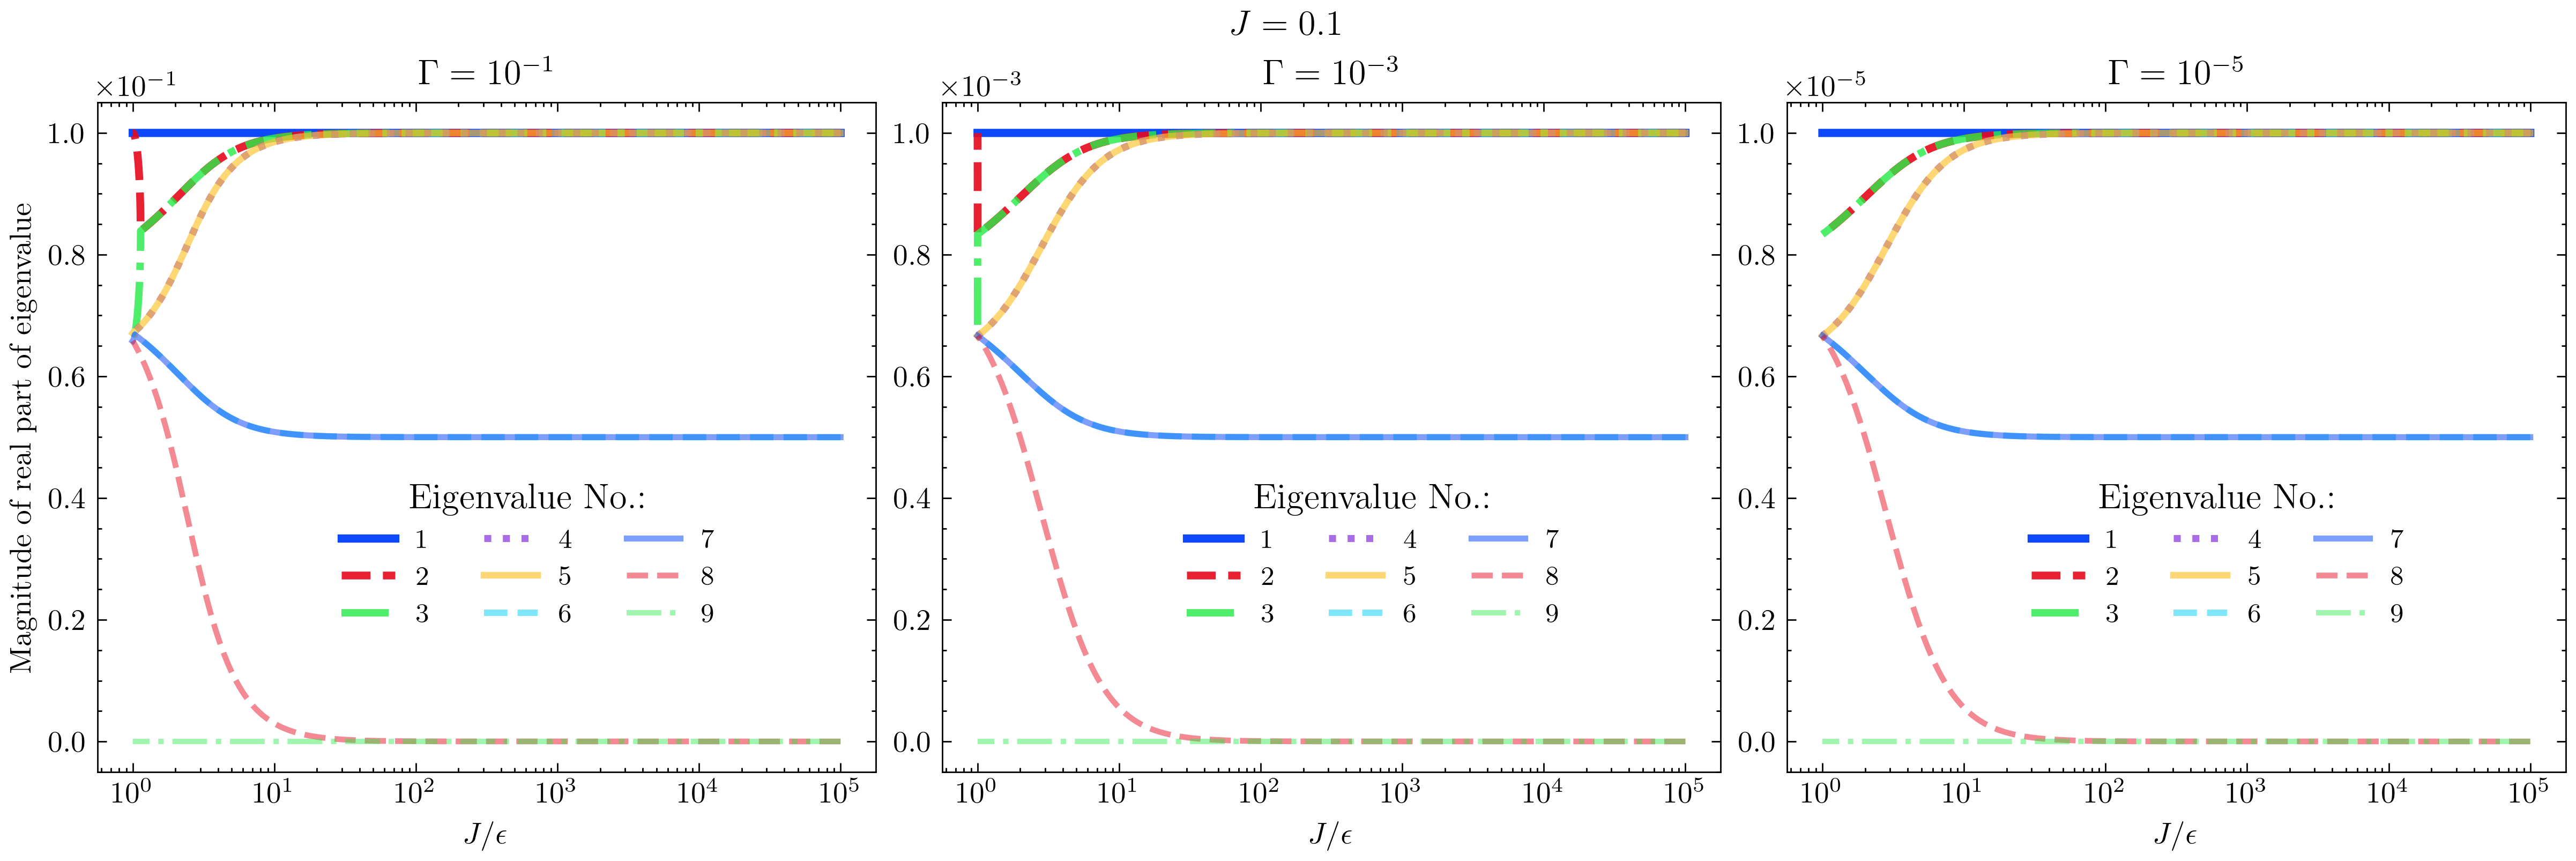

In [9]:
J_val = 0.1


datas = [
    np.loadtxt("gamma=1e-1; J=0.1.dat", dtype=np.complex128),
    np.loadtxt("gamma=1e-3; J=0.1.dat", dtype=np.complex128),
    np.loadtxt("gamma=1e-5; J=0.1.dat", dtype=np.complex128),
]
gammas = [
    1e-1,
    1e-3,
    1e-5,
]



fig, axs = plt.subplots(1,3, figsize=(12, 4), layout='constrained')
plt.style.use(['science', 'high-vis'])



        
for col, data in enumerate(datas):
    eps = data[:, 0]
    evals = data[:, 1:]
    
    for i in range(evals.shape[1]//2):
        axs[col].plot(J_val/eps,
                       np.abs(evals[:, 2*i]),
                        label=f"{i+1}",
                        linewidth=2.75*0.95**i,
                        alpha=1*0.9**i)

    axs[col].legend(title='Eigenvalue No.:', title_fontsize=12, fontsize=9, ncol=3, loc=(0.3, 0.2)) # plotting legend
    axs[col].set_xscale('log') # setting log scale for x axis
    axs[col].set_xlabel(r"$J / \epsilon$") # labelling x axis
    #axs[col].invert_xaxis() # inverting x axis
    axs[col].ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # using sci notation for y axis
    #axs[col].set_ylim([-1*gamma_val*0.2, gamma_val*1.2]) # forcing bounds of y axis (so that large magnitudes don't blow up the plot)
    axs[col].set_title(fr'$\Gamma=10^{{{int(np.log10(gammas[col]))}}}$')

axs[0].set_ylabel('Magnitude of real part of eigenvalue')  # labelling y axis
fig.suptitle(fr'$J={J_val}$')      
fig.savefig("splitting_numerically.pdf")
